## Data Preparation

#### Load Packages

In [2]:
import pandas as pd
import os
import time
import matplotlib.pyplot as plt

os.chdir("../")

#### Configuration

In [3]:
raw_file = "data/raw/HIGGS.csv"
output_directory = "data/processed"

sample_size = 200000
random_seed = 42

#### Load Dataset

In [4]:
print("Loading Dataset...")

start_time = time.time()

df = pd.read_csv(raw_file, header = None)

print(f"Runtime to read data in: {time.time()-start_time} seconds.")

Loading Dataset...
Runtime to read data in: 82.26047205924988 seconds.


In [5]:
print("Original dataset shape:", df.shape)

Original dataset shape: (11000000, 29)


#### Clean Data

- Assign Column Names

- Check for missing values and remove rows with missing values

- Check for duplicate rows and remove

- Check for outliers

##### Define Column Names

In [6]:
df.columns = ['label',
                     'lepton_pT', 'lepton_eta', 'lepton_phi',
                     'missing_E_mag', 'missing_E_phi',
                     'jet1_pT', 'jet1_eta', 'jet1_phi', 'jet1_btag',
                     'jet2_pT', 'jet2_eta', 'jet2_phi', 'jet2_btag',
                     'jet3_pT', 'jet3_eta', 'jet3_phi', 'jet3_btag',
                     'jet4_pT', 'jet4_eta', 'jet4_phi', 'jet4_btag',
                     'm_jj', 'm_jjj', 'm_lv', 'm_jlv',
                     'm_bb', 'm_wbb', 'm_wwbb']

print(f"Number of columns: {len(df.columns)}")


Number of columns: 29


#### Class Balance before Cleaning

In [7]:
df["label"].value_counts(normalize=True)

label
1.0    0.52992
0.0    0.47008
Name: proportion, dtype: float64

##### Check for missing values

In [8]:
df.isnull().values.any()

False

There are no missing values. 

##### Check and inspect duplicate rows

In [9]:
dups = df[df.duplicated(keep=False)]

dups_sorted = dups.sort_values(by=list(df.columns))

dups_sorted.head(10)

,label,lepton_pT,lepton_eta,lepton_phi,missing_E_mag,missing_E_phi,jet1_pT,jet1_eta,jet1_phi,jet1_btag,...,jet4_eta,jet4_phi,jet4_btag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
1570855,0.0,0.274697,-2.321996,0.065890,1.757651,-0.746459,0.805960,-0.987285,0.872193,0.000000,...,-1.074803,-1.421952,3.101961,0.779278,0.833811,0.988420,0.780893,0.337200,0.560171,0.685993
5891330,0.0,0.274697,-2.321996,0.065890,1.757651,-0.746459,0.805960,-0.987285,0.872193,0.000000,...,-1.074803,-1.421952,3.101961,0.779278,0.833811,0.988420,0.780893,0.337200,0.560171,0.685993
686644,0.0,0.274697,-2.235312,0.971979,1.210029,0.587197,0.636029,0.368340,-0.968993,0.000000,...,0.019527,1.307766,0.000000,0.862941,0.808005,0.974019,0.899918,0.972899,0.681085,0.689589
10531252,0.0,0.274697,-2.235312,0.971979,1.210029,0.587197,0.636029,0.368340,-0.968993,0.000000,...,0.019527,1.307766,0.000000,0.862941,0.808005,0.974019,0.899918,0.972899,0.681085,0.689589
4798519,0.0,0.274697,-1.765859,-1.158794,2.625344,-0.471526,0.794051,-0.554554,0.909891,0.000000,...,-1.078134,0.233457,1.550981,0.950832,0.807710,0.982367,1.477176,0.674255,1.028664,1.349287
7709738,0.0,0.274697,-1.765859,-1.158794,2.625344,-0.471526,0.794051,-0.554554,0.909891,0.000000,...,-1.078134,0.233457,1.550981,0.950832,0.807710,0.982367,1.477176,0.674255,1.028664,1.349287
7775769,0.0,0.274697,-1.610999,0.923706,0.633314,-1.230291,0.821808,-0.940744,0.081100,2.173076,...,-0.767491,-0.456957,0.000000,0.641802,0.826932,0.983703,0.812112,1.173764,0.799212,0.731625
8315277,0.0,0.274697,-1.610999,0.923706,0.633314,-1.230291,0.821808,-0.940744,0.081100,2.173076,...,-0.767491,-0.456957,0.000000,0.641802,0.826932,0.983703,0.812112,1.173764,0.799212,0.731625
1866956,0.0,0.274697,-1.466851,-1.110521,0.618773,-0.632611,1.633173,0.069291,-0.521609,2.173076,...,-0.032941,0.703467,3.101961,1.098137,0.958471,0.975211,0.795513,1.321068,1.416512,1.125085
8679169,0.0,0.274697,-1.466851,-1.110521,0.618773,-0.632611,1.633173,0.069291,-0.521609,2.173076,...,-0.032941,0.703467,3.101961,1.098137,0.958471,0.975211,0.795513,1.321068,1.416512,1.125085


In [10]:
dups['label'].value_counts()

label
0.0    553272
Name: count, dtype: int64

In [11]:
df['label'].value_counts()

label
1.0    5829123
0.0    5170877
Name: count, dtype: int64

In [12]:
print(f"There are {len(dups)/2} duplicated rows.")

There are 276636.0 duplicated rows.


In [13]:
df.nunique().sort_values()

label                  2
jet4_btag              3
jet1_btag              3
jet3_btag              3
jet2_btag              3
lepton_eta          5001
jet4_eta            5999
jet1_eta            5999
jet2_eta            5999
jet3_eta            5999
lepton_phi          6284
jet4_phi            6284
jet1_phi            6284
jet2_phi            6284
jet3_phi            6284
jet4_pT            19881
jet3_pT            27073
lepton_pT          27983
jet2_pT            37793
jet1_pT            45559
m_lv              344267
m_jjj             495814
m_jlv             524126
m_wbb             691289
m_wwbb            767597
m_jj             1068674
m_bb             1127135
missing_E_mag    1249475
missing_E_phi    2218464
dtype: int64

Duplicates were not removed because they are likely separate physical events that have taken place but have resulted in identical recorded measurements. This can occur because of rounding/truncating values. There are also several features that contain relatively few unique values compared to the 11 million rows of data. As a result, different physical events can share the exact same recorded feature values, leading to duplicate rows in the dataset. Additionally, the large size of the dataset increases the likelihood that different observations will share identical recorded feature values, which can result in duplicate rows. Removing these duplicates could distort the true distribution of events, so they were kept for analysis. 

Duplicate rows are only observed in the background class. This suggests that the duplicates likely arise from background processes producing identical recorded feature values rather than from data errors.

##### Check for outliers

In [14]:
q1 = df.drop("label", axis = 1).quantile(0.25)
q3 = df.drop("label", axis = 1).quantile(0.75)
iqr = q3 - q1

outliers = ((df.drop("label", axis = 1) < (q1 - 1.5 * iqr)) | (df.drop("label", axis = 1) > (q3 + 1.5 * iqr)))

outlier_count = outliers.sum()
rows_with_outliers = outliers.any(axis = 1).sum()

print(outlier_count)
print(f"There are {rows_with_outliers} rows with at least 1 outlier.")

lepton_pT         429914
lepton_eta             0
lepton_phi             0
missing_E_mag     325478
missing_E_phi          0
jet1_pT           544742
jet1_eta           69639
jet1_phi               0
jet1_btag              0
jet2_pT           441388
jet2_eta           49965
jet2_phi               0
jet2_btag              0
jet3_pT           353352
jet3_eta               0
jet3_phi               0
jet3_btag              0
jet4_pT           370313
jet4_eta               0
jet4_phi               0
jet4_btag              0
m_jj             1535805
m_jjj             823177
m_lv             2185644
m_jlv             562323
m_bb              666944
m_wbb             690031
m_wwbb            659860
dtype: int64
There are 5178143 rows with at least 1 outlier.


There are many outliers detected in the dataset, but they are were not removed. The HIGGS dataset was originally created to identify rare partical events, meaning extreme values may correspond to meaningful physical phenomena rather than errors in the data. Removing these observations could eliminate important information needed to distinguish signal events from background events.

#### Make Sample Dataset for Scalability

K-means Time complexity is 

$$
O(t \cdot k \cdot n) 
$$

where 

- $n$ = number of data points

- $K$ = number of clusters

- $t$ = number of iterations

* From Lecture notes week 5

In [15]:
complexity_estimate = 2 * len(df)

print(f"The time complexity for K-means on the full dataset is approximately {complexity_estimate}. This means the number of distance operations needed is at least {complexity_estimate}, when the number of iterations is 1.")

The time complexity for K-means on the full dataset is approximately 22000000. This means the number of distance operations needed is at least 22000000, when the number of iterations is 1.


Showing the complexity of K-means, the decision is made to conduct a random sample on the cleaned dataset to have a total of 200,000 observations. 200,000 observations was picked per the project guidelines as methods do not scale. A sample of 200k observations is still large enough to preserve the overall structure of the data while making clustering, PCA, and metric evaluation computationally reasonable. 

In [16]:
df_sample = df.sample(n=sample_size, random_state = random_seed)

print("Sampled dataset shape:", df_sample.shape)
df_sample.head()

Sampled dataset shape: (200000, 29)


,label,lepton_pT,lepton_eta,lepton_phi,missing_E_mag,missing_E_phi,jet1_pT,jet1_eta,jet1_phi,jet1_btag,...,jet4_eta,jet4_phi,jet4_btag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
3967303,0.0,1.138683,-0.726635,-0.005790,0.204118,0.153842,1.585904,-0.045576,-1.448527,1.086538,...,-2.439800,0.073642,0.000000,1.790497,1.730592,0.980587,0.743065,2.378752,1.534863,1.227558
5946179,1.0,0.404633,1.014821,-1.050041,1.136441,-1.403536,3.218436,-1.944837,0.801788,0.000000,...,-1.174742,-0.912542,0.000000,1.072789,0.649697,0.981147,2.004577,0.521853,1.246037,1.461494
6910558,0.0,1.137585,0.325251,1.453598,0.804114,0.893516,0.418095,-1.164536,-0.585919,0.000000,...,0.280201,-0.982461,3.101961,0.816500,0.933867,0.988956,0.852772,0.415455,0.737194,0.691437
3414332,0.0,1.380438,-0.595149,-0.727112,0.465392,-0.057453,0.399224,-0.076273,1.080084,2.173076,...,1.261267,1.129085,0.000000,0.563342,0.857068,0.992465,0.875139,0.512037,0.686362,0.887047
5840458,1.0,0.962628,1.191110,-1.161568,1.541759,0.569159,1.337374,0.810973,0.458075,1.086538,...,0.413452,1.309431,3.101961,1.596246,1.146864,1.687726,1.178736,0.925320,1.094308,0.991339


#### Split features and targets

In [17]:
X = df_sample.drop(columns="label")
y = df_sample["label"]

#### Check Balance of Target

In [22]:
sample_balance = y.value_counts(normalize=True)
full_balance = df["label"].value_counts(normalize=True)

balance_df = pd.DataFrame({
    "Full Dataset": full_balance,
    "Sample Dataset": sample_balance
})

print(balance_df)

       Full Dataset  Sample Dataset
label                              
1.0         0.52992        0.529345
0.0         0.47008        0.470655


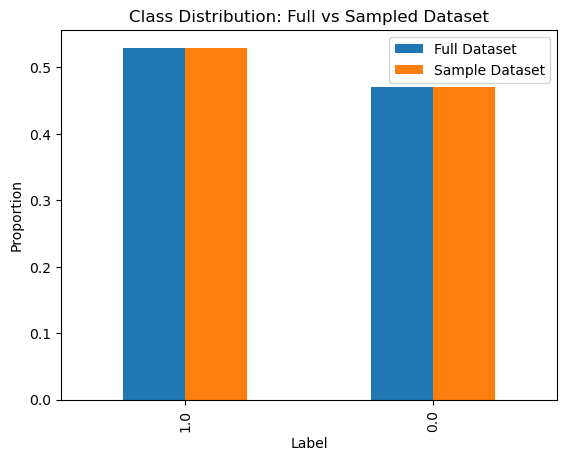

<Figure size 640x480 with 0 Axes>

In [23]:
os.makedirs("../results/visualizations", exist_ok=True)

balance_df.plot(kind="bar")
plt.title("Class Distribution: Full vs Sampled Dataset")
plt.xlabel("Label")
plt.ylabel("Proportion")
plt.legend()
plt.show()
plt.savefig("results/visualizations/dataset_balance.png")

#### Create Results Table

In [20]:
os.makedirs("results/metrics", exist_ok=True)

columns = ["method", "dataset_version", "n_clusters", "n_rows", "n_features", "training_time_seconds", "prediction_time_seconds", "iterations", "accuracy", "silhouette_score", "davies_bouldin", "compactness", "separation"]

df_summary = pd.DataFrame(columns=columns)

print("Created clustering_summary.csv to keep results in one place.")

Created clustering_summary.csv to keep results in one place.


#### Save Processed Files

In [ ]:
df_sample.to_csv(f"{output_directory}/higgs_sample.csv", index = False)
print("Saved higgs_sample.csv")

X.to_csv(f"{output_directory}/X_sample.csv", index = False)
print("Saved X_sample.csv")

y.to_csv(f"{output_directory}/Y_sample.csv", index = False)
print("Saved y_sample.csv")

df_summary.to_csv("results/metrics/clustering_summary.csv", index=False)
print("Saved clustering_summary.csv")


Saved higgs_sample.csv
Saved X_sample.csv
Saved y_sample.csv
Saved clustering_summary.csv
